#### Langchain Starts
This notebook shows how to use `langchain_ollama` to connect LangChain to a locally running Ollama runtime at `http://localhost:11434`.
No OpenAI API key is needed; the model runs locally on your machine.

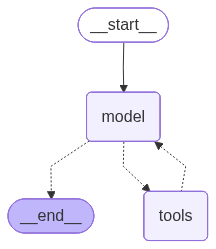

In [1]:
import os
from langchain.agents import create_agent
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2:3b",
    base_url=os.getenv("BASE_URL", "http://localhost:11434"),
    validate_model_on_init=False,
)

def get_weather(city: str):
    """Return a simple weather report for the requested city."""
    return f"The weather in {city} is sunny with a high of 25 degrees Celsius."

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant.",
)

agent


In [2]:
agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in New York?"}]}
)

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='5ca082eb-356e-4dbd-b926-0df70eafb23e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-06-07T18:53:02.0006696Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10087594900, 'load_duration': 6450044200, 'prompt_eval_count': 165, 'prompt_eval_duration': 2581908000, 'eval_count': 18, 'eval_duration': 1042790000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019ea36e-3744-7f20-a461-f09d5afb0f61-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': '82d65784-b0b8-4e47-b451-6144fcda1fbe', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 18, 'total_tokens': 183}),
  ToolMessage(content='The weather in New York is sunny with a high of 25 degrees Celsius.', name='get_weather', id='6dc45172-1bc5-4

In [3]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the capital of India?"}]}
)

print(response)

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='f6f5336d-5bc6-4a38-b65d-1a5f730ff69e'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-06-07T18:53:10.8595841Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1528114600, 'load_duration': 270493700, 'prompt_eval_count': 164, 'prompt_eval_duration': 204997000, 'eval_count': 18, 'eval_duration': 1037761000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019ea36e-8352-7771-aa8a-1749b1293ebe-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New Delhi'}, 'id': '3def0141-7943-49e9-a77c-165d9f112b5a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 164, 'output_tokens': 18, 'total_tokens': 182}), ToolMessage(content='The weather in New Delhi is sunny with a high of 25 degrees Celsius.', name='get_weather', id='fa1af004-fa14-4811-b562

In [4]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Give me the easiest example of a langchain agent?"}]}
)

print(response)

{'messages': [HumanMessage(content='Give me the easiest example of a langchain agent?', additional_kwargs={}, response_metadata={}, id='9ec705da-11d1-433d-995a-48754759eb6f'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-06-07T18:53:15.7526259Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1710263100, 'load_duration': 265863100, 'prompt_eval_count': 168, 'prompt_eval_duration': 282711000, 'eval_count': 18, 'eval_duration': 1140732000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019ea36e-95b7-7a22-ba54-5dd3a86187cc-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': '90957d7a-6349-47df-82ee-4d8049ba4257', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 168, 'output_tokens': 18, 'total_tokens': 186}), ToolMessage(content='The weather in New York is sunny with a high of 25 degrees Celsius.', name='get_weather', id='d3d2b

In [5]:
response = llm.invoke("How are u ?")
response.content

"I'm just a language model, so I don't have emotions or feelings like humans do. However, I'm functioning properly and ready to assist you with any questions or tasks you may have! How can I help you today?"

In [6]:
response = llm.stream("How are u ?")
for chunk in response:
    print(chunk.content, end="", flush=True)    

I'm just a language model, so I don't have feelings or emotions like humans do. However, I'm functioning properly and ready to assist you with any questions or tasks you may have! How can I help you today?

Streaming 
 streaming refers to two distinct but highly complementary concepts: delivering real-time event data to AI agents and generating AI responses in real-time (token-by-token)

In [7]:
response = llm.stream("Write a 200 word essay on the benefits of using langchain for building AI applications in hindi.")
for chunk in response:
    print(chunk.text, end="", flush=True)

लैंगचेन (LangChain) एक ऐसा प्रौद्योगिकी है जो मशीन लर्निंग मॉडल्स के लिए विचार प्रबंधन और ऑपरेशनलाइजेशन को सुलभ बनाती है। इसके उपयोग से विकासकर्ताओं को अपने AI मॉडल्स को अधिक प्रभावी और कुशलता से चलाने में मदद मिलती है।

लैंगचेन का उपयोग करके, विकासकर्ताओं को अपने मॉडल्स के लिए विचार प्रबंधन करने में आसानी होती है, जिससे उन्हें अधिक संगठित और कुशलतापूर्वक चलाने में मदद मिलती है। इसके अलावा, यह मशीन लर्निंग मॉडल्स को डेटा प्रबंधन, ऑपरेशनलाइजेशन और प्रदर्शन में सुधार करने में मदद करता है।

लैंगचेन का उपयोग करके, विकासकर्ताओं को अपने AI मॉडल्स को अधिक कुशलतापूर्वक चलाने और उनकी दक्षता बढ़ाने में मदद मिलती है। इसके अलावा, यह

KeyboardInterrupt: 

Batch 
grouping data or tasks together so an autonomous AI agent can process them in bulk rather than handling them one by one

In [ ]:
response = llm.batch([
    "what is the capital of india ?",
    "what is the quantum computing ?",
    "what the dark matter ?"
])

for res in response:
    print(res.content)

The capital of India is New Delhi.
Quantum computing is a new paradigm for computing that uses the principles of quantum mechanics to perform calculations and operations on data. It's different from classical computing, which uses bits to store and process information.

In classical computing, information is represented as 0s and 1s, which can be thought of as a coin that can either be heads (0) or tails (1). In contrast, quantum computers use qubits (quantum bits), which can exist in multiple states simultaneously, represented by a combination of 0s and 1s.

This property, known as superposition, allows quantum computers to process multiple possibilities at the same time, making them potentially much faster than classical computers for certain types of calculations. Quantum computers also use entanglement, which is a phenomenon where qubits can be connected in such a way that their states are correlated, allowing for fast communication and processing.

Quantum computing has many poten

In [ ]:
from langchain_core.runnables import RunnableConfig


response = llm.batch(
    [
        "what is the capital of india ?",
        "what is the quantum computing ?",
        "what the dark matter ?"
    ],
    config=RunnableConfig(max_concurrency=2),
)

for res in response:
    print(res.content)


The capital of India is New Delhi.
Quantum Computing is a revolutionary new way of processing information that uses the principles of quantum mechanics to perform calculations and operations on data. It's a field that has the potential to solve problems that are currently unsolvable or require an unfeasible amount of time using classical computers.

Here's a brief overview:

**Classical Computing vs Quantum Computing**

Classical computers use bits, which can have a value of either 0 or 1. These bits are used to perform calculations and operations on data. However, as the size of the problem increases, classical computers become slower and more prone to errors.

Quantum computers, on the other hand, use quantum bits or qubits. Qubits can exist in multiple states simultaneously, which means they can process multiple possibilities at the same time. This allows quantum computers to perform certain calculations much faster than classical computers.

**Key Features of Quantum Computing**

1

response = llm.invoke("What is the tools in agentic ai")
response.content